## Test RAGES (Reasoning-based Autonomous Guidance Engine for Space) 

In [ ]:
from __future__ import annotations

import argparse
import json
import sys, os
from pathlib import Path
from typing import Any, Dict

# Force a single visible GPU so `device_map="auto"` does not shard across cuda:0/cuda:1.
visible = os.environ.get("CUDA_VISIBLE_DEVICES", "0")
os.environ["CUDA_VISIBLE_DEVICES"] = visible.split(",")[0].strip() or "0"

import matplotlib.pyplot as plt
import numpy as np
import torch

def find_root_path(path: str, word: str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path

root_folder = Path(find_root_path(os.getcwd(), 'art_lang'))
sys.path.append(str(root_folder))

from rpod.rages.rages import RAGES
from rpod.rages.datagen_reasoning import behavior_seq_to_text

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} | visible CUDA devices: {torch.cuda.device_count()}")

%load_ext autoreload
%autoreload 2

Using device: cuda:0 | visible CUDA devices: 1


In [ ]:
# construct RAGES (once) 
engine = RAGES(
    adapter_dir = root_folder / "rpod/rages/reasoning_model/v1/checkpoint-5200",
    base_model = "Qwen/Qwen2.5-7B-Instruct",
    wyp_ckpt_path = root_folder / "rpod/rages/wyp_model/model_gmm_v3_weighted_one_hot.pt",
    data_path = root_folder / "rpod/rages/wyp_data/data_v3_discrete.pth",
)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/home/yuji/.cache/pypoetry/virtualenvs/art-env-NbYBgrfa-py3.10/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# arguments
out_dir = root_folder / "rpod/rages/out"
out_dir = Path(out_dir)

In [4]:
# set up the input 

idx = 120
n = int(engine.data["x0"].shape[0])
if n <= 0:
    raise ValueError("Dataset is empty; cannot build test input.")
i = int(idx) % n

inputs = {
    "x0": engine.data["x0"][i].cpu().numpy(),
    "koz_param": engine.data["koz_dim"][i].cpu().numpy(),
    "artms_scaling_1e3": engine.data["artms_scale_range_1e3"][i].cpu().numpy(),
    "intent_priority": ["fuel", "time", "observation", "safety_margin"],
    "oec0_modified": engine.data["oec0_modified"][i].cpu().numpy(),
}

print(inputs) 
print("------------")

out = engine.intent_to_traj(inputs)


{'x0': array([  0. , 175. ,   0. ,   2.5,   0. ,   2.5], dtype=float32), 'koz_param': array([40., 40., 40.], dtype=float32), 'artms_scaling_1e3': array([1.e-04, 4.e-03, 2.e-03, 2.e-03, 2.e-03, 2.e-03], dtype=float32), 'intent_priority': ['fuel', 'time', 'observation', 'safety_margin'], 'oec0_modified': array([ 6.7381400e+06,  5.5810000e-04,  7.8414643e-01,  6.2057585e-01,
       -8.5683364e-01,  5.1559299e-01,  4.4121298e-01,  8.9740241e-01,
        8.0848598e-01,  5.8851540e-01], dtype=float32)}
------------
[RAGES] Generating reasoning and trajectory decisions from intent...
[RAGES] Reasoning output parsed. tf=68 b_seq=[8, 1, 9]
[RAGES] Waypoints are generated. SCP is being solved...


In [5]:
# high-level intent 
priority = out["input"]["intent_priority"]

# mid-level decisions 
reasoning = out["reasoning_output"]["reasoning"]
tf = out["reasoning_output"]["tf"]
b_seq = out["reasoning_output"]["b_seq"]

# status 
print("Status CVX: ", out["status"]["cvx"], " / Status SCP: ", out["status"]["scp"])

# waypoint 

# trajectory 
traj = out["trajectory"]
roe = traj.get("roe")
rtn = traj.get("rtn")
rtn_ct = traj.get("rtn_ct")
actions = traj.get("actions")
t_idx_wyp = traj.get("t_idx_wyp")


Status CVX:  optimal  / Status SCP:  optimal


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


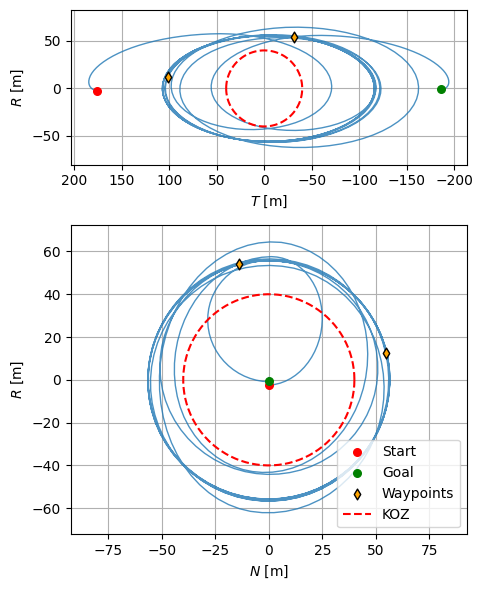

In [6]:
# plot trajectory (same style as test_wyp.ipynb)
phi = np.linspace(0, 2 * np.pi, 100)
koz_dim = inputs["koz_param"]   
x_circ = koz_dim[0] * np.cos(phi)
y_circ = koz_dim[0] * np.sin(phi)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(5, 6),
    gridspec_kw={"height_ratios": [1, 2]}  # ax1 is 3x taller than ax2
)

ax1.plot(rtn_ct[:, 1], rtn_ct[:, 0], linewidth=1, alpha=0.8)
ax2.plot(rtn_ct[:, 2], rtn_ct[:, 0], linewidth=1, alpha=0.8)

# boundary state 
ax1.scatter(rtn_ct[0, 1], rtn_ct[0, 0], color='r', s=30, label='Start', zorder=5)
ax2.scatter(rtn_ct[0, 2], rtn_ct[0, 0], color='r', s=30, label='Start', zorder=5)
ax1.scatter(rtn_ct[-1, 1], rtn_ct[-1, 0], color='g', s=30, label='Goal', zorder=5)
ax2.scatter(rtn_ct[-1, 2], rtn_ct[-1, 0], color='g', s=30, label='Goal', zorder=5)
if len(t_idx_wyp) > 0:
    ax1.scatter(rtn[t_idx_wyp, 1], rtn[t_idx_wyp, 0], color='orange', marker='d', edgecolors="black", s=30, label='Waypoints', zorder=5)
    ax2.scatter(rtn[t_idx_wyp, 2], rtn[t_idx_wyp, 0], color='orange', marker='d', edgecolors="black", s=30, label='Waypoints', zorder=5)
    

ax1.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax1.set_xlabel('$T$ [m]')
ax1.set_ylabel('$R$ [m]')
ax1.invert_xaxis()
ax1.grid()
ax1.axis('equal')

ax2.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax2.set_xlabel('$N$ [m]')
ax2.set_ylabel('$R$ [m]')

ax2.invert_xaxis()
ax2.grid()
ax2.axis('equal')
ax2.set_xlim(-100, 100)
ax2.set_ylim(-100, 100)
ax2.legend(loc='lower right')

behav_sentence = behavior_seq_to_text(b_seq)

# fig.suptitle(f"Intent (Priority): {priority}, \n x0 = {np.round(roe[0, :])} [m]  \n Reasoning: {reasoning} \n tf_steps={tf} | Behavior: {behav_sentence}")

plt.tight_layout()
plt.show()

fig.savefig(out_dir /"figures"/ f"test_rages_{idx}.png", dpi=600, bbox_inches='tight', pad_inches=0.02)

In [7]:
# print out the I/O summary 

from rpod.dynamics.dynamics_trans import restore_koe
from rpod.optimization.parameters import artms_scale_range_1e3

#### INPUTS ###### 
print("===== INPUTS =====")
# x0 
print(f"x0: {inputs['x0']}")
# intnent priority
print(f"Intent Priority: {priority}")
# Orital elements at t0
print(f"OEC0 (modified): {restore_koe(inputs['oec0_modified'])}")  
# r_koz 
print(f"KOZ (R): {koz_dim[0]} [m]")
# beta (navigation uncertainty) 
print(f"ARTMS Scaling (beta): {inputs['artms_scaling_1e3'][0] / artms_scale_range_1e3[0] :.3f} ")


#### OUTPUTS ######
print("\n===== OUTPUTS =====")
# behavior sequence
print(f"Behavior Sequence: {b_seq} | {behav_sentence}")
# time step (steps) 
print(f"Time Steps (tf): {tf} steps")
# reasoning
print(f"Reasoning: {reasoning}")
# waypoints
print("ROE waypoints: ", out["trajectory"]["wyp"])
# waypoints time step
print("Waypoints time (step): ", t_idx_wyp)

===== INPUTS =====
x0: [  0.  175.    0.    2.5   0.    2.5]
Intent Priority: ['fuel', 'time', 'observation', 'safety_margin']
OEC0 (modified): [ 6.7381400e+06  5.5810000e-04  9.0131950e-01 -1.0290967e+00
  4.5694989e-01  9.4157505e-01]
KOZ (R): 40.0 [m]
ARTMS Scaling (beta): 1.000 

===== OUTPUTS =====
Behavior Sequence: [8, 1, 9] | Approach from +V-bar -> Station-Keeping -> Retreat to -V-bar
Time Steps (tf): 68 steps
Reasoning: It seems to lead to low delta-v while maintaining a reasonable transfer time.
ROE waypoints:  [[ 1.9879208e-05 -9.3960009e+00 -1.7266033e-06  5.6690720e+01
  -3.0893527e-06  5.6040955e+01]
 [-1.5301310e-05 -4.4100208e+00  9.6722151e-06  5.5759682e+01
  -2.2744700e-06  5.6529404e+01]
 [ 6.1834885e-06 -1.8756747e+02 -8.1172544e-07  9.1530418e-01
  -2.2501787e-05 -1.8558502e-02]]
Waypoints time (step):  [20, 46]
